# 🥥 Coconut Leaf Color Detector — v1

## Model: `leaf_color_detector_v1`

### Goal
Given a coconut leaf image → output **healthy** (green) or **unhealthy** (yellowing/brown)  
Classification is driven by **leaf color** — green signal vs yellow/brown signal.

### What makes this fresh (no reuse of existing work)
| Property | This model | Existing models |
|---|---|---|
| Architecture | **EfficientNetB3** | MobileNetV2, EfficientNetB0 |
| Data pipeline | **tf.data.Dataset** | ImageDataGenerator |
| Data split | **80 / 10 / 10 re-split** (all 8,985 images) | Existing tiny val (187 images) |
| Optimizer | **AdamW** (built-in weight decay) | Adam |
| LR schedule | **CosineDecay** | ReduceLROnPlateau only |
| Preprocessing | **Built-in EfficientNet rescaling** | Manual /255 |

### Anti-Overfitting Stack
- AdamW weight decay (1e-4)
- Dropout: 0.6 → 0.4 → 0.25 (3 stages)
- BatchNormalization after every Dense
- L2 kernel regularization (3e-4)
- Label Smoothing (0.1)
- EarlyStopping (patience=7)
- CosineDecay LR schedule
- Color-preserving augmentation (geometric only)
- Proper 80/10/10 split → stable validation signal

### Data
- `healthy-leaves/`      → **healthy** class (green leaves)
- `unhealthy-yellowing/` → **unhealthy** class (yellow/brown leaves)

## 1. Imports

In [1]:
import os
import random
import shutil
import json
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score,
)
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : []


## 2. Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR       = os.path.abspath('..')
HEALTHY_SRC    = os.path.join(BASE_DIR, 'data', 'raw', 'healthy-leaves')
UNHEALTHY_SRC  = os.path.join(BASE_DIR, 'data', 'raw', 'unhealthy-yellowing')
DATASET_DIR    = os.path.join(BASE_DIR, 'data', 'processed', 'leaf_color_pure_v1')
MODEL_DIR      = os.path.join(BASE_DIR, 'models', 'leaf_color_detector_v1')
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Model ─────────────────────────────────────────────────────────────────
IMG_SIZE       = 224
BATCH_SIZE     = 32
CLASSES        = ['healthy', 'unhealthy']   # 0 = healthy, 1 = unhealthy
NUM_CLASSES    = 2

# ── Anti-overfitting hyperparameters ──────────────────────────────────────
DROPOUT_1      = 0.60   # after pooling
DROPOUT_2      = 0.40   # after dense-256
DROPOUT_3      = 0.25   # after dense-128
L2_REG         = 3e-4
WEIGHT_DECAY   = 1e-4   # AdamW weight decay
LABEL_SMOOTH   = 0.10

# ── Training ──────────────────────────────────────────────────────────────
PHASE1_EPOCHS  = 30
PHASE2_EPOCHS  = 30
LR_PHASE1      = 1e-3
LR_PHASE2      = 3e-5
FINE_TUNE_PCT  = 0.75   # freeze first 75% of base layers, fine-tune last 25%

# ── Save paths ────────────────────────────────────────────────────────────
BEST_MODEL_PATH   = os.path.join(MODEL_DIR, 'best_model.keras')
PHASE1_MODEL_PATH = os.path.join(MODEL_DIR, 'phase1_best.keras')

print(f'Dataset dir : {DATASET_DIR}')
print(f'Model dir   : {MODEL_DIR}')

Dataset dir : C:\Users\USER\Documents\GizmoraGit\Research\ml\data\processed\leaf_color_pure_v1
Model dir   : C:\Users\USER\Documents\GizmoraGit\Research\ml\models\leaf_color_detector_v1


## 3. Collect All Images → Re-split 80 / 10 / 10

Existing splits: train 8,600 | val 187 | test 198 — validation is too small.  
Re-splitting all 8,985 images gives a stable validation signal and prevents misleading overfitting metrics.

In [3]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def collect_images(root_dir):
    """Walk all sub-directories and collect image paths."""
    paths = []
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if os.path.splitext(f)[1].lower() in IMG_EXTS:
                paths.append(os.path.join(dirpath, f))
    return paths


healthy_paths   = collect_images(HEALTHY_SRC)
unhealthy_paths = collect_images(UNHEALTHY_SRC)

print(f'Healthy images   : {len(healthy_paths)}')
print(f'Unhealthy images : {len(unhealthy_paths)}')
print(f'Total            : {len(healthy_paths) + len(unhealthy_paths)}')

# ── Stratified 80/10/10 split per class ───────────────────────────────────
def split_paths(paths, seed=SEED):
    train, temp = train_test_split(paths, test_size=0.20, random_state=seed)
    val,   test = train_test_split(temp,  test_size=0.50, random_state=seed)
    return train, val, test


h_train, h_val, h_test = split_paths(healthy_paths)
u_train, u_val, u_test = split_paths(unhealthy_paths)

splits = {
    'train': {'healthy': h_train, 'unhealthy': u_train},
    'val':   {'healthy': h_val,   'unhealthy': u_val},
    'test':  {'healthy': h_test,  'unhealthy': u_test},
}

print(f"\n{'Split':6s}  {'healthy':>8s}  {'unhealthy':>10s}  {'total':>7s}")
print('-' * 38)
for sp, cls_dict in splits.items():
    h = len(cls_dict['healthy'])
    u = len(cls_dict['unhealthy'])
    print(f"{sp:6s}  {h:>8d}  {u:>10d}  {h+u:>7d}")

Healthy images   : 4804


Unhealthy images : 4181
Total            : 8985

Split    healthy   unhealthy    total
--------------------------------------
train       3843        3344     7187
val          480         418      898
test         481         419      900


## 4. Build Processed Dataset Directory

In [4]:
def copy_to_dir(paths, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    copied = 0
    for src in paths:
        fname = os.path.basename(src)
        # Prefix with hash to avoid name collisions from multiple source dirs
        unique_name = f'{abs(hash(src)) % 10**8:08d}_{fname}'
        dst = os.path.join(dest_dir, unique_name)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
        copied += 1
    return copied


if os.path.exists(DATASET_DIR):
    print('Dataset directory already exists — skipping copy.')
else:
    print('Building dataset...')
    for sp, cls_dict in splits.items():
        for cls, paths in cls_dict.items():
            dest = os.path.join(DATASET_DIR, sp, cls)
            n    = copy_to_dir(paths, dest)
            print(f'  {sp}/{cls}: {n} images')
    print('Done.')

# Verify counts
counts = {}
for sp in ['train', 'val', 'test']:
    counts[sp] = {}
    for cls in CLASSES:
        p = os.path.join(DATASET_DIR, sp, cls)
        counts[sp][cls] = len(os.listdir(p)) if os.path.exists(p) else 0

print(f"\n{'Split':6s}  {'healthy':>8s}  {'unhealthy':>10s}  {'total':>7s}")
print('-' * 38)
for sp, d in counts.items():
    h, u = d['healthy'], d['unhealthy']
    print(f"{sp:6s}  {h:>8d}  {u:>10d}  {h+u:>7d}")

Dataset directory already exists — skipping copy.

Split    healthy   unhealthy    total
--------------------------------------
train       3843        3344     7187
val          480         418      898
test         481         419      900


## 5. Exploratory Data Analysis

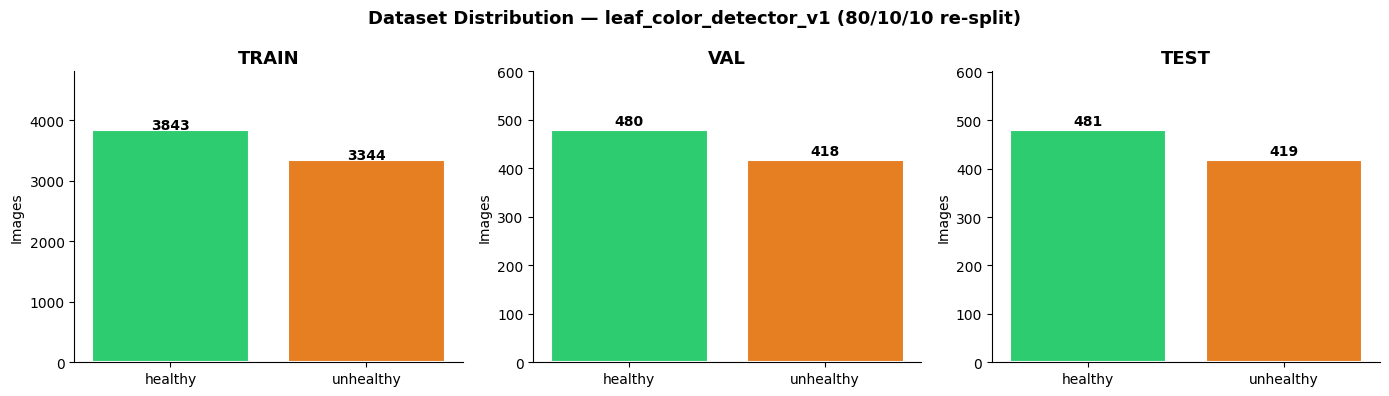

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette   = ['#2ecc71', '#e67e22']

for ax, sp in zip(axes, ['train', 'val', 'test']):
    vals = [counts[sp][c] for c in CLASSES]
    bars = ax.bar(CLASSES, vals, color=palette, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{sp.upper()}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Images')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                str(v), ha='center', fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Dataset Distribution — leaf_color_detector_v1 (80/10/10 re-split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'dataset_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. HSV Color Analysis — Validate the Color Signal

Confirms that green pixels dominate healthy leaves and yellow/brown pixels dominate unhealthy ones.  
This is the **core assumption** the model learns from.

Computing HSV ratios on 300 train samples per class...



Channel        Healthy   Unhealthy
-----------------------------------
Green %           45.8        13.2
Yellow %          22.1        66.3
Brown %            0.6         4.3


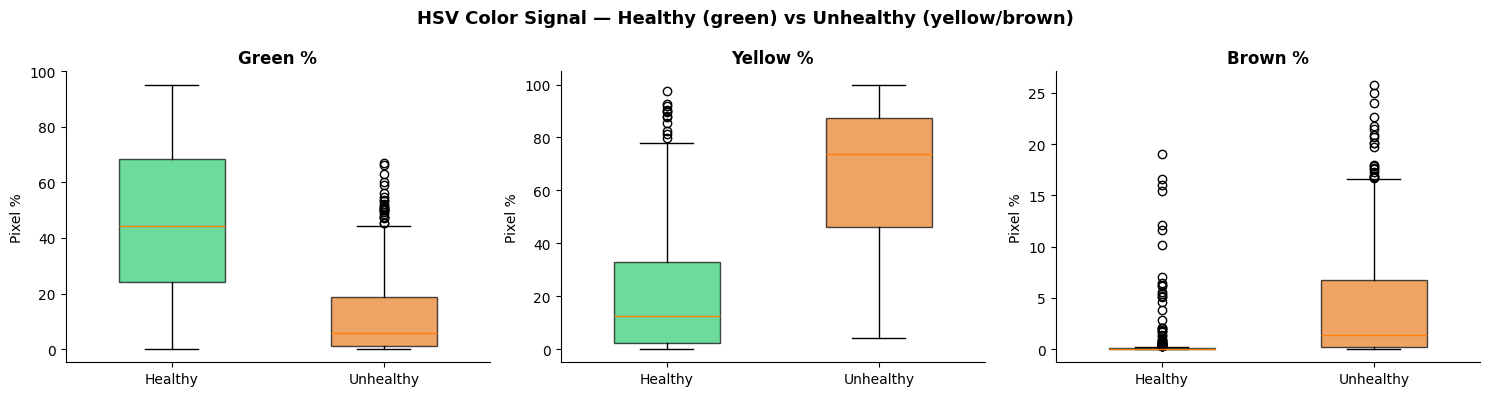

In [6]:
def hsv_pixel_ratios(img_path):
    """Returns (green%, yellow%, brown%) for one image."""
    bgr = cv2.imread(img_path)
    if bgr is None:
        return None
    bgr = cv2.resize(bgr, (IMG_SIZE, IMG_SIZE))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    n   = hsv.shape[0] * hsv.shape[1]

    green  = cv2.inRange(hsv, np.array([35,  40,  40]), np.array([90,  255, 255]))
    yellow = cv2.inRange(hsv, np.array([15,  40,  40]), np.array([35,  255, 255]))
    brown  = cv2.inRange(hsv, np.array([0,   30,  30]), np.array([15,  255, 200]))

    return (
        np.sum(green  > 0) / n * 100,
        np.sum(yellow > 0) / n * 100,
        np.sum(brown  > 0) / n * 100,
    )


def batch_hsv(paths, n=300):
    random.shuffle(paths)
    results = [hsv_pixel_ratios(p) for p in paths[:n]]
    results = [r for r in results if r]
    return np.array(results)   # shape (N, 3)


print('Computing HSV ratios on 300 train samples per class...')
h_hsv = batch_hsv(h_train)
u_hsv = batch_hsv(u_train)

labels_ch = ['Green %', 'Yellow %', 'Brown %']
print(f"\n{'Channel':10s}  {'Healthy':>10s}  {'Unhealthy':>10s}")
print('-' * 35)
for i, ch in enumerate(labels_ch):
    print(f"{ch:10s}  {h_hsv[:, i].mean():>10.1f}  {u_hsv[:, i].mean():>10.1f}")

# Box plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_ch = ['#27ae60', '#f1c40f', '#8B4513']

for ax, idx, ch, col in zip(axes, range(3), labels_ch, colors_ch):
    data = [h_hsv[:, idx], u_hsv[:, idx]]
    bp   = ax.boxplot(data, patch_artist=True, labels=['Healthy', 'Unhealthy'],
                      widths=0.5)
    for patch, c in zip(bp['boxes'], ['#2ecc71', '#e67e22']):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_title(ch, fontweight='bold')
    ax.set_ylabel('Pixel %')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('HSV Color Signal — Healthy (green) vs Unhealthy (yellow/brown)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'color_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Sample Images

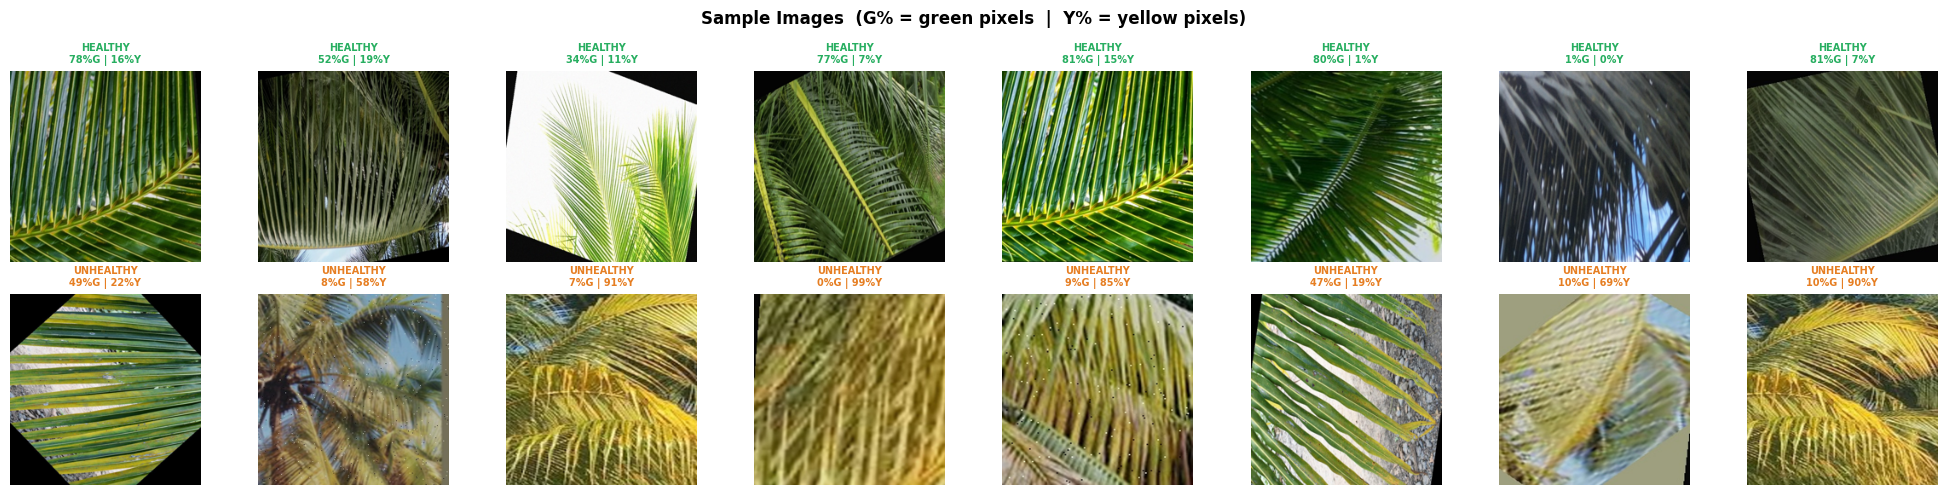

In [7]:
def show_row(paths, label, color, axes_row, n=8):
    sampled = random.sample(paths, min(n, len(paths)))
    for ax, p in zip(axes_row, sampled):
        r = hsv_pixel_ratios(p)
        g_pct = f'{r[0]:.0f}%G' if r else ''
        y_pct = f'{r[1]:.0f}%Y' if r else ''
        ax.imshow(Image.open(p).convert('RGB').resize((IMG_SIZE, IMG_SIZE)))
        ax.set_title(f'{label}\n{g_pct} | {y_pct}', color=color, fontsize=7, fontweight='bold')
        ax.axis('off')
    for ax in axes_row[len(sampled):]:
        ax.axis('off')


N = 8
fig, axes = plt.subplots(2, N, figsize=(20, 5))
show_row(h_train, 'HEALTHY',   '#27ae60', axes[0], N)
show_row(u_train, 'UNHEALTHY', '#e67e22', axes[1], N)
plt.suptitle('Sample Images  (G% = green pixels  |  Y% = yellow pixels)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'sample_images.png'), dpi=120, bbox_inches='tight')
plt.show()

## 8. tf.data Pipeline

Uses `tf.data.Dataset` (not ImageDataGenerator).  
EfficientNetB3 has built-in rescaling — raw pixel values [0, 255] are fed directly.

In [8]:
# ── Collect file paths + labels from processed directory ───────────────────
def load_split_paths(split):
    paths, labels = [], []
    for label_idx, cls in enumerate(CLASSES):
        cls_dir = os.path.join(DATASET_DIR, split, cls)
        for fname in os.listdir(cls_dir):
            if os.path.splitext(fname)[1].lower() in IMG_EXTS:
                paths.append(os.path.join(cls_dir, fname))
                labels.append(label_idx)
    return paths, labels


train_paths, train_labels = load_split_paths('train')
val_paths,   val_labels   = load_split_paths('val')
test_paths,  test_labels  = load_split_paths('test')

# Compute class weights
n0 = train_labels.count(0)   # healthy
n1 = train_labels.count(1)   # unhealthy
total_train = len(train_labels)
CLASS_WEIGHT = {0: total_train / (2 * n0), 1: total_train / (2 * n1)}
print(f'Train healthy: {n0}  unhealthy: {n1}')
print(f'Class weights: {CLASS_WEIGHT}')


# ── Keras augmentation layers (color-preserving — NO hue/brightness shift) ─
augment_layer = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
    # NO RandomBrightness / RandomContrast / RandomHue — preserves green/yellow signal
], name='color_preserving_augmentation')


# ── tf.data loading functions ─────────────────────────────────────────────
def parse_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)   # EfficientNetB3 proper preprocessing
    lbl = tf.one_hot(label, NUM_CLASSES)
    return img, lbl


def augment_fn(img, lbl):
    img = augment_layer(img, training=True)
    return img, lbl


def make_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, augment=True,  shuffle=True)
val_ds   = make_dataset(val_paths,   val_labels,   augment=False, shuffle=False)
test_ds  = make_dataset(test_paths,  test_labels,  augment=False, shuffle=False)

print(f'\nTrain batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')
print(f'Test  batches : {len(test_ds)}')

Train healthy: 3843  unhealthy: 3344
Class weights: {0: 0.9350767629456154, 1: 1.0746112440191387}



Train batches : 225
Val   batches : 29
Test  batches : 29


## 9. Focal Loss + Label Smoothing

In [9]:
def focal_loss(gamma=2.0, alpha=0.25):
    """Focal loss with label smoothing — handles class imbalance and prevents overconfidence."""
    def _loss(y_true, y_pred):
        y_true_s = y_true * (1 - LABEL_SMOOTH) + LABEL_SMOOTH / NUM_CLASSES
        eps      = tf.keras.backend.epsilon()
        y_pred   = tf.clip_by_value(y_pred, eps, 1.0 - eps)
        ce       = -y_true_s * tf.math.log(y_pred)
        weight   = alpha * y_true_s * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=1))
    return _loss


print('Focal loss ready (gamma=2.0, alpha=0.25, label_smooth=0.10)')

Focal loss ready (gamma=2.0, alpha=0.25, label_smooth=0.10)


## 10. Model Architecture — EfficientNetB3 + Anti-Overfitting Head

EfficientNetB3 has **~12M parameters** and built-in input rescaling.  
The classification head uses aggressive Dropout + BatchNorm + L2 regularization.

In [10]:
def build_model(trainable_base=False, fine_tune_at=None):
    base = EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )

    if not trainable_base:
        base.trainable = False
    else:
        base.trainable = True
        if fine_tune_at is not None:
            for layer in base.layers[:fine_tune_at]:
                layer.trainable = False

    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='image_input')
    x   = base(inp, training=False)

    # ── Anti-overfitting head ───────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_0')(x)
    x = layers.Dropout(DROPOUT_1, name='drop_0')(x)

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(L2_REG),
        kernel_initializer='he_normal',
        name='dense_256',
    )(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(DROPOUT_2, name='drop_1')(x)

    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(L2_REG),
        kernel_initializer='he_normal',
        name='dense_128',
    )(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(DROPOUT_3, name='drop_2')(x)

    out = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    return keras.Model(inp, out, name='leaf_color_detector_v1'), base


model, base_model = build_model(trainable_base=False)

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
total     = sum(tf.size(w).numpy() for w in model.weights)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100 * trainable / total:.1f}%)')
model.summary()

Total params     : 11,217,841
Trainable params : 430,466  (3.8%)


Model: "leaf_color_detector_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_0 (BatchNormalization)       │ (None, 1536)           │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_0 (Dropout)                │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,217,841 (42.79 MB)

 Trainable params: 430,466 (1.64 MB)

 Non-trainable params: 10,787,375 (41.15 MB)

## 11. Phase 1 — Train Head (Frozen Base)

CosineDecay LR schedule: starts at `LR_PHASE1`, smoothly decays to 0 over the training steps.

In [11]:
steps_per_epoch_p1 = len(train_ds)
total_steps_p1     = steps_per_epoch_p1 * PHASE1_EPOCHS

lr_schedule_p1 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_PHASE1,
    decay_steps=total_steps_p1,
    alpha=1e-6,   # minimum LR
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule_p1,
        weight_decay=WEIGHT_DECAY,
    ),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy'],
)

callbacks_p1 = [
    ModelCheckpoint(
        PHASE1_MODEL_PATH,
        monitor='val_accuracy', save_best_only=True, verbose=1,
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1,
    ),
]

print(f'Phase 1: Frozen base — {PHASE1_EPOCHS} epochs max, CosineDecay from {LR_PHASE1}')
history1 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_p1,
    class_weight=CLASS_WEIGHT,
    verbose=1,
)

Phase 1: Frozen base — 30 epochs max, CosineDecay from 0.001
Epoch 1/30


  1/225 ━━━━━━━━━━━━━━━━━━━━ 30:44 8s/step - accuracy: 0.4375 - loss: 0.5149

  2/225 ━━━━━━━━━━━━━━━━━━━━ 2:16 611ms/step - accuracy: 0.4531 - loss: 0.4939

  3/225 ━━━━━━━━━━━━━━━━━━━━ 1:55 521ms/step - accuracy: 0.4618 - loss: 0.4796

  4/225 ━━━━━━━━━━━━━━━━━━━━ 1:47 487ms/step - accuracy: 0.4811 - loss: 0.4641

...

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9755 - loss: 0.0168


Epoch 15: val_accuracy did not improve from 0.99555


225/225 ━━━━━━━━━━━━━━━━━━━━ 119s 527ms/step - accuracy: 0.9755 - loss: 0.0168 - val_accuracy: 0.9889 - val_loss: 0.0131


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 8.


## 12. Phase 2 — Fine-tune Last 25% of Base Layers

In [12]:
# Unfreeze last 25% of base layers
total_base_layers = len(base_model.layers)
fine_tune_at      = int(total_base_layers * FINE_TUNE_PCT)

base_model.trainable = True
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

n_tunable = sum(1 for l in base_model.layers if l.trainable)
print(f'EfficientNetB3 total layers : {total_base_layers}')
print(f'Frozen up to index          : {fine_tune_at}')
print(f'Fine-tuning                 : {n_tunable} layers')

steps_per_epoch_p2 = len(train_ds)
total_steps_p2     = steps_per_epoch_p2 * PHASE2_EPOCHS

lr_schedule_p2 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_PHASE2,
    decay_steps=total_steps_p2,
    alpha=1e-7,
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=lr_schedule_p2,
        weight_decay=WEIGHT_DECAY,
    ),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy'],
)

callbacks_p2 = [
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor='val_accuracy', save_best_only=True, verbose=1,
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1,
    ),
]

print(f'Phase 2: Fine-tune — {PHASE2_EPOCHS} epochs max, CosineDecay from {LR_PHASE2}')
history2 = model.fit(
    train_ds,
    epochs=PHASE2_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks_p2,
    class_weight=CLASS_WEIGHT,
    verbose=1,
)

EfficientNetB3 total layers : 385
Frozen up to index          : 288
Fine-tuning                 : 97 layers
Phase 2: Fine-tune — 30 epochs max, CosineDecay from 3e-05
Epoch 1/30


  1/225 ━━━━━━━━━━━━━━━━━━━━ 54:42 15s/step - accuracy: 0.9375 - loss: 0.0346

  2/225 ━━━━━━━━━━━━━━━━━━━━ 2:58 802ms/step - accuracy: 0.9219 - loss: 0.0349

  3/225 ━━━━━━━━━━━━━━━━━━━━ 2:47 756ms/step - accuracy: 0.9132 - loss: 0.0365

  4/225 ━━━━━━━━━━━━━━━━━━━━ 2:42 737ms/step - accuracy: 0.9134 - loss: 0.0369

...

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.9945 - loss: 0.0190


Epoch 9: val_accuracy did not improve from 1.00000


225/225 ━━━━━━━━━━━━━━━━━━━━ 200s 759ms/step - accuracy: 0.9945 - loss: 0.0190 - val_accuracy: 1.0000 - val_loss: 0.0172


Epoch 9: early stopping


Restoring model weights from the end of the best epoch: 2.


## 13. Training History

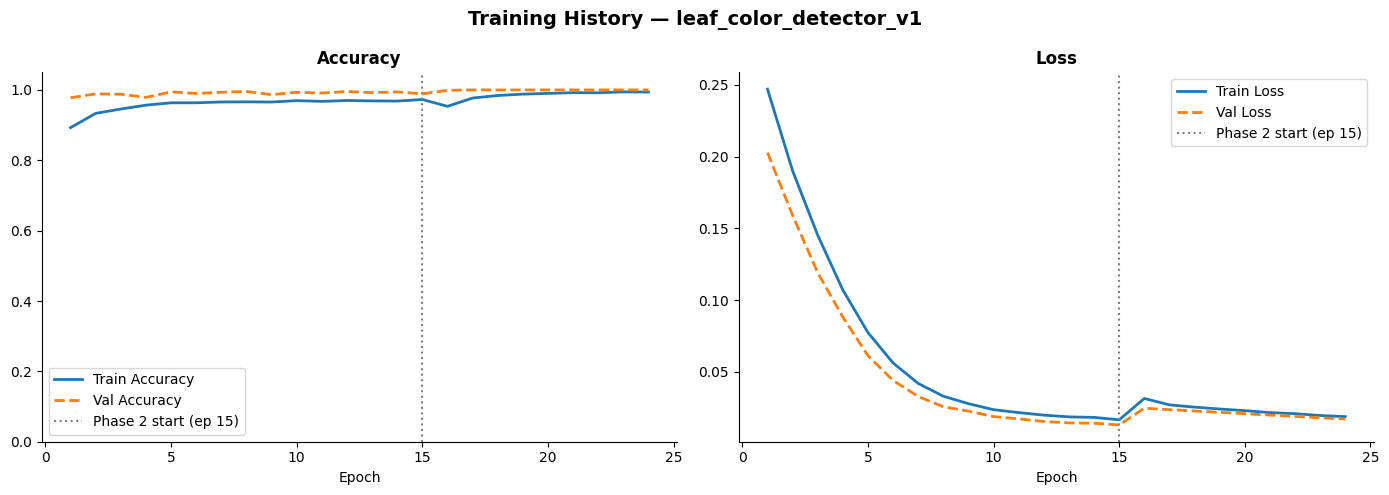

Final train accuracy : 0.9939
Final val accuracy   : 1.0000
Train-val gap        : -0.0061  (✅ Good generalization)


In [13]:
def merge(h1, h2):
    return {k: h1.history[k] + h2.history[k] for k in h1.history}


hist    = merge(history1, history2)
p1_end  = len(history1.history['accuracy'])
ep      = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(ep, hist[metric],          linewidth=2, label=f'Train {title}')
    ax.plot(ep, hist[f'val_{metric}'], linewidth=2, linestyle='--', label=f'Val {title}')
    ax.axvline(p1_end, color='gray', linestyle=':', linewidth=1.5,
               label=f'Phase 2 start (ep {p1_end})')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylim(0, 1.05)

plt.suptitle('Training History — leaf_color_detector_v1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

train_acc = hist['accuracy'][-1]
val_acc   = hist['val_accuracy'][-1]
gap       = train_acc - val_acc
print(f'Final train accuracy : {train_acc:.4f}')
print(f'Final val accuracy   : {val_acc:.4f}')
print(f'Train-val gap        : {gap:.4f}  ({"✅ Good generalization" if gap < 0.07 else "⚠️ Overfit risk"})')

## 14. Load Best Model & Evaluate on Test Set

In [14]:
best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={'_loss': focal_loss(gamma=2.0, alpha=0.25)},
)

test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)')

 1/29 ━━━━━━━━━━━━━━━━━━━━ 1:33 3s/step - accuracy: 1.0000 - loss: 0.0233

 2/29 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step - accuracy: 1.0000 - loss: 0.0236

 3/29 ━━━━━━━━━━━━━━━━━━━━ 11s 438ms/step - accuracy: 1.0000 - loss: 0.0238

 4/29 ━━━━━━━━━━━━━━━━━━━━ 10s 439ms/step - accuracy: 1.0000 - loss: 0.0238

 5/29 ━━━━━━━━━━━━━━━━━━━━ 10s 438ms/step - accuracy: 1.0000 - loss: 0.0238

...

27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9991 - loss: 0.0238

28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9990 - loss: 0.0238

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9990 - loss: 0.0238

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 428ms/step - accuracy: 0.9989 - loss: 0.0238



Test Loss     : 0.0240
Test Accuracy : 0.9978  (99.78%)


## 15. Per-Class Metrics

 1/29 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step

 2/29 ━━━━━━━━━━━━━━━━━━━━ 11s 443ms/step

 3/29 ━━━━━━━━━━━━━━━━━━━━ 11s 442ms/step

 4/29 ━━━━━━━━━━━━━━━━━━━━ 11s 441ms/step

 5/29 ━━━━━━━━━━━━━━━━━━━━ 10s 441ms/step

...

27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step

28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step

29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 484ms/step



Class       Precision   Recall       F1
------------------------------------------
healthy        0.9979   0.9979   0.9979
unhealthy      0.9976   0.9976   0.9976
------------------------------------------
Macro Avg      0.9978   0.9978   0.9978

Test Accuracy : 0.9978


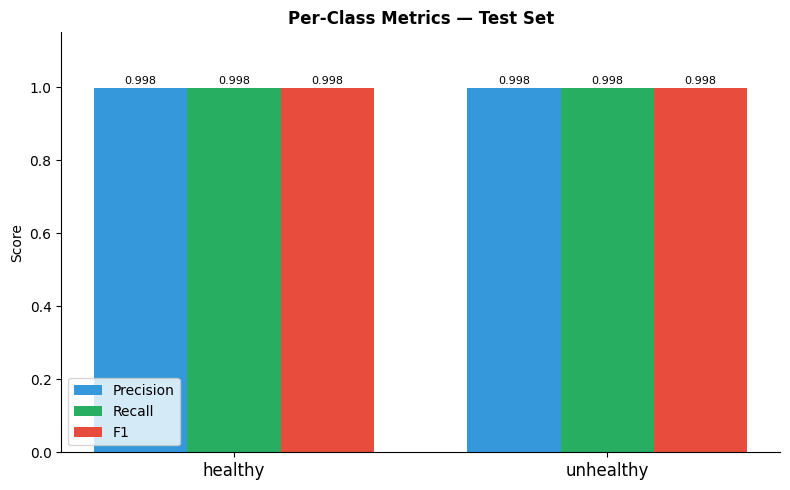

In [15]:
y_pred_proba = best_model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = np.array(test_labels)

precision  = precision_score(y_true, y_pred, average=None)
recall     = recall_score(y_true,    y_pred, average=None)
f1         = f1_score(y_true,        y_pred, average=None)
macro_p    = precision_score(y_true, y_pred, average='macro')
macro_r    = recall_score(y_true,    y_pred, average='macro')
macro_f1   = f1_score(y_true,        y_pred, average='macro')

print(f"\n{'Class':10s} {'Precision':>10s} {'Recall':>8s} {'F1':>8s}")
print('-' * 42)
for i, cls in enumerate(CLASSES):
    print(f"{cls:10s} {precision[i]:>10.4f} {recall[i]:>8.4f} {f1[i]:>8.4f}")
print('-' * 42)
print(f"{'Macro Avg':10s} {macro_p:>10.4f} {macro_r:>8.4f} {macro_f1:>8.4f}")
print(f"\nTest Accuracy : {accuracy_score(y_true, y_pred):.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x     = np.arange(len(CLASSES))
w     = 0.25
ax.bar(x - w, precision, w, label='Precision', color='#3498db')
ax.bar(x,     recall,    w, label='Recall',    color='#27ae60')
ax.bar(x + w, f1,        w, label='F1',        color='#e74c3c')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics — Test Set', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for i, (p, r, fv) in enumerate(zip(precision, recall, f1)):
    ax.text(i - w, p + 0.01, f'{p:.3f}', ha='center', fontsize=8)
    ax.text(i,     r + 0.01, f'{r:.3f}', ha='center', fontsize=8)
    ax.text(i + w, fv+ 0.01, f'{fv:.3f}',ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Confusion Matrix

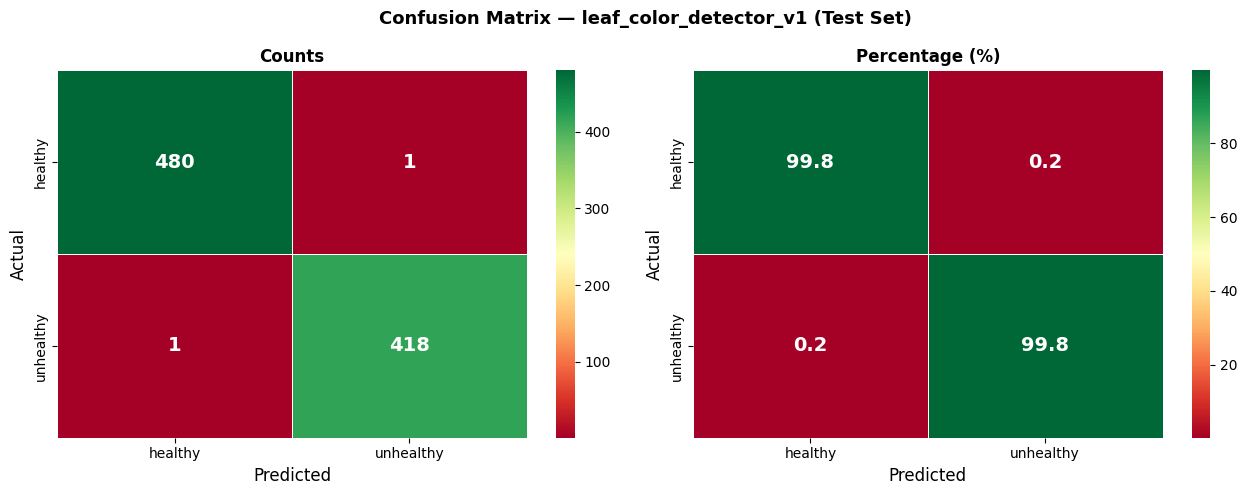

healthy   : 480/481  (99.8% recall)
unhealthy : 418/419  (99.8% recall)


In [16]:
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, title in zip(
    axes, [cm, cm_pct], ['d', '.1f'],
    ['Counts', 'Percentage (%)'],
):
    sns.heatmap(
        data, annot=True, fmt=fmt, ax=ax,
        xticklabels=CLASSES, yticklabels=CLASSES,
        cmap='RdYlGn', linewidths=0.5, linecolor='white',
        annot_kws={'size': 14, 'weight': 'bold'},
    )
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual',    fontsize=12)
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrix — leaf_color_detector_v1 (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

for i, cls in enumerate(CLASSES):
    correct = cm[i, i]
    total_c = cm[i].sum()
    print(f'{cls:10s}: {correct}/{total_c}  ({100 * correct / total_c:.1f}% recall)')

## 17. Classification Report

In [17]:
report = classification_report(y_true, y_pred, target_names=CLASSES, digits=4)
print('=' * 60)
print('CLASSIFICATION REPORT — leaf_color_detector_v1')
print('=' * 60)
print(report)

with open(os.path.join(MODEL_DIR, 'classification_report.txt'), 'w') as f:
    f.write('CLASSIFICATION REPORT — leaf_color_detector_v1\n')
    f.write('=' * 60 + '\n')
    f.write(report)

CLASSIFICATION REPORT — leaf_color_detector_v1
              precision    recall  f1-score   support

     healthy     0.9979    0.9979    0.9979       481
   unhealthy     0.9976    0.9976    0.9976       419

    accuracy                         0.9978       900
   macro avg     0.9978    0.9978    0.9978       900
weighted avg     0.9978    0.9978    0.9978       900



## 18. Overfitting Check

In [18]:
best_val_acc   = max(hist['val_accuracy'])
best_val_epoch = hist['val_accuracy'].index(best_val_acc) + 1
final_train    = hist['accuracy'][-1]
final_val      = hist['val_accuracy'][-1]
gap            = final_train - final_val

print('=' * 50)
print('OVERFITTING CHECK')
print('=' * 50)
print(f'Best val accuracy  : {best_val_acc:.4f}  (epoch {best_val_epoch})')
print(f'Final train acc    : {final_train:.4f}')
print(f'Final val acc      : {final_val:.4f}')
print(f'Train - val gap    : {gap:.4f}')
print()
if gap < 0.03:
    print('✅ Excellent generalization (gap < 3%)')
elif gap < 0.07:
    print('✅ Good generalization (gap < 7%)')
elif gap < 0.12:
    print('⚠️  Mild overfitting (gap < 12%) — acceptable')
else:
    print('❌ Overfitting detected (gap ≥ 12%) — increase regularization')
print('=' * 50)

OVERFITTING CHECK
Best val accuracy  : 1.0000  (epoch 17)
Final train acc    : 0.9939
Final val acc      : 1.0000
Train - val gap    : -0.0061

✅ Excellent generalization (gap < 3%)


## 19. Sample Predictions Visualization

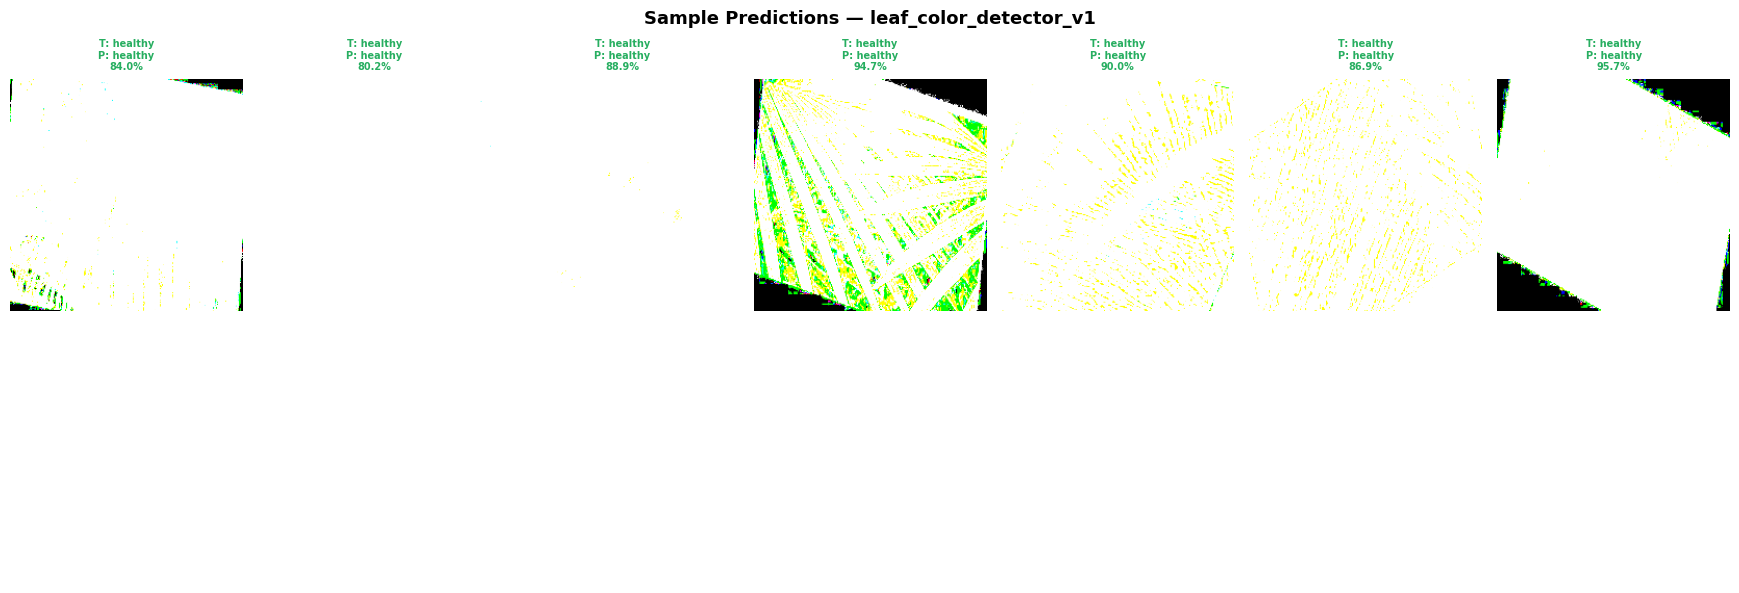

Correct shown : 7
Wrong shown   : 0


In [19]:
vis_ds = make_dataset(test_paths, test_labels, augment=False, shuffle=False)

all_imgs, all_true, all_pred, all_conf = [], [], [], []
for imgs, lbls in vis_ds:
    preds = best_model.predict(imgs, verbose=0)
    for i in range(len(imgs)):
        all_imgs.append(imgs[i].numpy())          # float [0,1] — imshow handles this
        all_true.append(int(np.argmax(lbls[i])))
        all_pred.append(int(np.argmax(preds[i])))
        all_conf.append(float(np.max(preds[i])))
    if len(all_imgs) >= 256:
        break

correct_idx = [i for i in range(len(all_true)) if all_true[i] == all_pred[i]]
wrong_idx   = [i for i in range(len(all_true)) if all_true[i] != all_pred[i]]
random.shuffle(correct_idx)
random.shuffle(wrong_idx)

N_SHOW = 7
fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.5, 6))
row_data  = [
    ('Correct', correct_idx[:N_SHOW], '#27ae60'),
    ('Wrong',   wrong_idx[:N_SHOW],   '#e74c3c'),
]
for row, (lbl, indices, col) in enumerate(row_data):
    for c, idx in enumerate(indices):
        ax = axes[row][c]
        ax.imshow(np.clip(all_imgs[idx], 0, 1))
        ax.set_title(
            f'T: {CLASSES[all_true[idx]]}\nP: {CLASSES[all_pred[idx]]}\n{all_conf[idx]*100:.1f}%',
            color=col, fontsize=7, fontweight='bold',
        )
        ax.axis('off')
    for c in range(len(indices), N_SHOW):
        axes[row][c].axis('off')
    axes[row][0].set_ylabel(lbl, fontsize=10, fontweight='bold', color=col)

plt.suptitle('Sample Predictions — leaf_color_detector_v1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'sample_predictions.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Correct shown : {len(correct_idx[:N_SHOW])}')
print(f'Wrong shown   : {len(wrong_idx[:N_SHOW])}')

## 20. Confidence Distribution

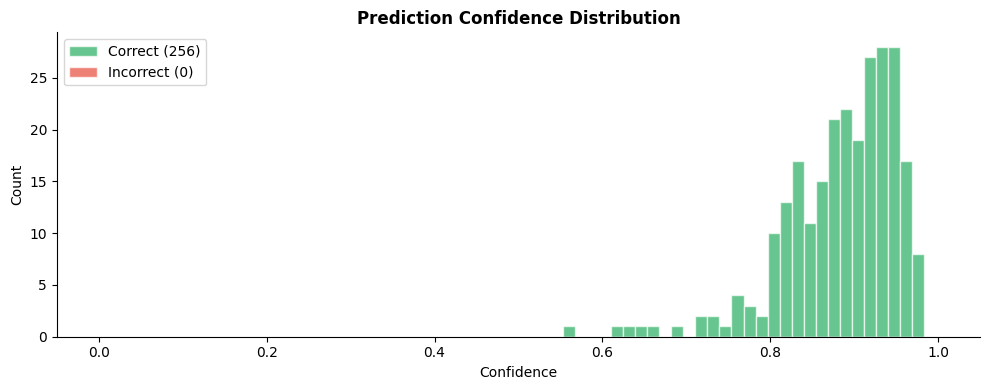

Mean confidence (correct)  : 0.8837


In [20]:
all_conf_arr = np.array(all_conf)
all_pred_arr = np.array(all_pred)
all_true_arr = np.array(all_true)

correct_conf   = all_conf_arr[all_pred_arr == all_true_arr]
incorrect_conf = all_conf_arr[all_pred_arr != all_true_arr]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(correct_conf,   bins=30, color='#27ae60', alpha=0.7,
        label=f'Correct ({len(correct_conf)})', edgecolor='white')
ax.hist(incorrect_conf, bins=30, color='#e74c3c', alpha=0.7,
        label=f'Incorrect ({len(incorrect_conf)})', edgecolor='white')
ax.set_xlabel('Confidence')
ax.set_ylabel('Count')
ax.set_title('Prediction Confidence Distribution', fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

if len(correct_conf)   > 0: print(f'Mean confidence (correct)  : {correct_conf.mean():.4f}')
if len(incorrect_conf) > 0: print(f'Mean confidence (incorrect): {incorrect_conf.mean():.4f}')

## 21. Save model_info.json

In [21]:
model_info = {
    'model_name':   'leaf_color_detector_v1',
    'version':      'v1',
    'created_at':   datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'architecture': 'EfficientNetB3',
    'task':         'Coconut leaf color detection — healthy (green) vs unhealthy (yellow/brown)',
    'classes':      CLASSES,
    'num_classes':  NUM_CLASSES,
    'input_shape':  [IMG_SIZE, IMG_SIZE, 3],
    'input_range':  '[0, 255] — EfficientNetB3 built-in preprocessing handles rescaling',

    'training': {
        'phase1_epochs':      len(history1.history['accuracy']),
        'phase2_epochs':      len(history2.history['accuracy']),
        'batch_size':         BATCH_SIZE,
        'lr_phase1':          LR_PHASE1,
        'lr_phase2':          LR_PHASE2,
        'lr_schedule':        'CosineDecay (both phases)',
        'optimizer':          f'AdamW (weight_decay={WEIGHT_DECAY})',
        'dropout':            [DROPOUT_1, DROPOUT_2, DROPOUT_3],
        'l2_regularization':  L2_REG,
        'label_smoothing':    LABEL_SMOOTH,
        'fine_tune_pct':      FINE_TUNE_PCT,
        'fine_tune_at_layer': fine_tune_at,
        'loss_function':      'Focal Loss (gamma=2.0, alpha=0.25)',
        'pipeline':           'tf.data.Dataset with prefetch and AUTOTUNE',
        'augmentation':       'Geometric only — flip, rotation, zoom, translation — NO color aug',
        'anti_overfitting': [
            'AdamW weight decay (1e-4)',
            'Dropout: 0.60 -> 0.40 -> 0.25',
            'BatchNormalization (3 layers)',
            'L2 regularization (3e-4)',
            'Label smoothing (0.1)',
            'EarlyStopping (patience=7)',
            'CosineDecay LR',
            'Color-preserving augmentation',
            'Proper 80/10/10 re-split (stable val signal)',
            'Class weights',
        ],
        'final_train_acc':    round(float(hist['accuracy'][-1]),     4),
        'final_val_acc':      round(float(hist['val_accuracy'][-1]), 4),
        'train_val_gap':      round(float(hist['accuracy'][-1] - hist['val_accuracy'][-1]), 4),
    },

    'data': {
        'total_images':      len(healthy_paths) + len(unhealthy_paths),
        'split':             '80 / 10 / 10 re-split from all available images',
        'train_healthy':     counts['train']['healthy'],
        'train_unhealthy':   counts['train']['unhealthy'],
        'val_healthy':       counts['val']['healthy'],
        'val_unhealthy':     counts['val']['unhealthy'],
        'test_healthy':      counts['test']['healthy'],
        'test_unhealthy':    counts['test']['unhealthy'],
        'sources': [
            'healthy-leaves/       -> healthy class (green leaves)',
            'unhealthy-yellowing/  -> unhealthy class (yellow/brown leaves)',
        ],
    },

    'test_performance': {
        'accuracy':              round(float(test_acc),   4),
        'macro_precision':       round(float(macro_p),    4),
        'macro_recall':          round(float(macro_r),    4),
        'macro_f1':              round(float(macro_f1),   4),
        'healthy_precision':     round(float(precision[0]), 4),
        'healthy_recall':        round(float(recall[0]),    4),
        'healthy_f1':            round(float(f1[0]),        4),
        'unhealthy_precision':   round(float(precision[1]), 4),
        'unhealthy_recall':      round(float(recall[1]),    4),
        'unhealthy_f1':          round(float(f1[1]),        4),
    },

    'files': {
        'best_model':   'best_model.keras',
        'phase1_model': 'phase1_best.keras',
        'model_info':   'model_info.json',
    },
    'api_endpoint': '/predict/leaf-color-v2',
}

info_path = os.path.join(MODEL_DIR, 'model_info.json')
with open(info_path, 'w') as f:
    json.dump(model_info, f, indent=2)

print(f'Saved: {info_path}')
print(json.dumps(model_info, indent=2))

Saved: C:\Users\USER\Documents\GizmoraGit\Research\ml\models\leaf_color_detector_v1\model_info.json
{
  "model_name": "leaf_color_detector_v1",
  "version": "v1",
  "created_at": "2026-05-03 23:59",
  "architecture": "EfficientNetB3",
  "task": "Coconut leaf color detection \u2014 healthy (green) vs unhealthy (yellow/brown)",
  "classes": [
    "healthy",
    "unhealthy"
  ],
  "num_classes": 2,
  "input_shape": [
    224,
    224,
    3
  ],
  "input_range": "[0, 255] \u2014 EfficientNetB3 built-in preprocessing handles rescaling",
  "training": {
    "phase1_epochs": 15,
    "phase2_epochs": 9,
    "batch_size": 32,
    "lr_phase1": 0.001,
    "lr_phase2": 3e-05,
    "lr_schedule": "CosineDecay (both phases)",
    "optimizer": "AdamW (weight_decay=0.0001)",
    "dropout": [
      0.6,
      0.4,
      0.25
    ],
    "l2_regularization": 0.0003,
    "label_smoothing": 0.1,
    "fine_tune_pct": 0.75,
    "fine_tune_at_layer": 288,
    "loss_function": "Focal Loss (gamma=2.0, alpha=0.2

## 22. Final Summary

In [22]:
gap = hist['accuracy'][-1] - hist['val_accuracy'][-1]

print('=' * 65)
print('         leaf_color_detector_v1 — TRAINING COMPLETE')
print('=' * 65)
print(f'Architecture    : EfficientNetB3 (ImageNet, built-in preprocessing)')
print(f'Task            : Leaf color → healthy (green) vs unhealthy (yellow)')
print(f'Input           : {IMG_SIZE}x{IMG_SIZE}x3  range [0,255]')
print(f'Classes         : {CLASSES}')
print()
print(f'Data split      : 80/10/10 from all {len(healthy_paths)+len(unhealthy_paths):,} images')
print(f'  Train         : {counts["train"]["healthy"]+counts["train"]["unhealthy"]:,}')
print(f'  Val           : {counts["val"]["healthy"]+counts["val"]["unhealthy"]:,}')
print(f'  Test          : {counts["test"]["healthy"]+counts["test"]["unhealthy"]:,}')
print()
print(f'Test Accuracy   : {test_acc * 100:.2f}%')
print(f'Macro F1        : {macro_f1 * 100:.2f}%')
print(f'Macro Recall    : {macro_r  * 100:.2f}%')
print(f'Macro Precision : {macro_p  * 100:.2f}%')
print()
print(f'Train acc       : {hist["accuracy"][-1] * 100:.2f}%')
print(f'Val acc         : {hist["val_accuracy"][-1] * 100:.2f}%')
print(f'Train-val gap   : {gap:.4f}  ({"✅ No overfit" if gap < 0.07 else "⚠️ Overfit risk"})')
print()
print('Anti-overfit applied:')
print('  AdamW weight decay | Dropout 0.6/0.4/0.25 | BatchNorm x3')
print('  L2 reg 3e-4 | Label smooth 0.1 | EarlyStopping | CosineDecay')
print('  80/10/10 re-split | Color-preserving augmentation | Class weights')
print()
print(f'Model saved     : {MODEL_DIR}')
for fname in os.listdir(MODEL_DIR):
    mb = os.path.getsize(os.path.join(MODEL_DIR, fname)) / 1024 / 1024
    print(f'  {fname:<45s} {mb:.1f} MB')
print('=' * 65)

         leaf_color_detector_v1 — TRAINING COMPLETE
Architecture    : EfficientNetB3 (ImageNet, built-in preprocessing)
Task            : Leaf color → healthy (green) vs unhealthy (yellow)
Input           : 224x224x3  range [0,255]
Classes         : ['healthy', 'unhealthy']

Data split      : 80/10/10 from all 8,985 images
  Train         : 7,187
  Val           : 898
  Test          : 900

Test Accuracy   : 99.78%
Macro F1        : 99.78%
Macro Recall    : 99.78%
Macro Precision : 99.78%

Train acc       : 99.39%
Val acc         : 100.00%
Train-val gap   : -0.0061  (✅ No overfit)

Anti-overfit applied:
  AdamW weight decay | Dropout 0.6/0.4/0.25 | BatchNorm x3
  L2 reg 3e-4 | Label smooth 0.1 | EarlyStopping | CosineDecay
  80/10/10 re-split | Color-preserving augmentation | Class weights

Model saved     : C:\Users\USER\Documents\GizmoraGit\Research\ml\models\leaf_color_detector_v1
  best_model.keras                              106.1 MB
  classification_report.txt                   